In [2]:
pip install matplotlib==3.8.4

  Using cached matplotlib-3.8.4-cp312-cp312-win_amd64.whl.metadata (5.9 kB)
Using cached matplotlib-3.8.4-cp312-cp312-win_amd64.whl (7.7 MB)
Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mlxtend 0.24.0 requires matplotlib>=3.10.8, but you have matplotlib 3.8.4 which is incompatible.

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import matplotlib.pyplot as plt
print("Working ✅")

Working ✅


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
df=pd.read_csv('placement.csv')
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123,1
1,1,5.9,106,0
2,2,5.3,121,0
3,3,7.4,132,1
4,4,5.8,142,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    int64  
 3   placement   100 non-null    int64  
dtypes: float64(1), int64(3)
memory usage: 3.3 KB


In [7]:
df.shape

(100, 4)

In [8]:
#preprocessing
df=df.iloc[:,1:]

In [9]:
df.head()

,cgpa,iq,placement
0,6.8,123,1
1,5.9,106,0
2,5.3,121,0
3,7.4,132,1
4,5.8,142,0


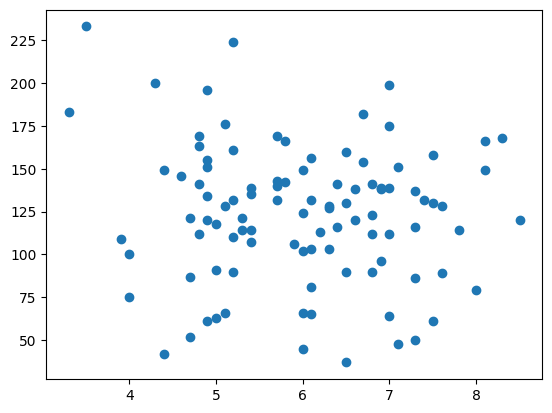

In [10]:
plt.scatter(df['cgpa'],df['iq'])

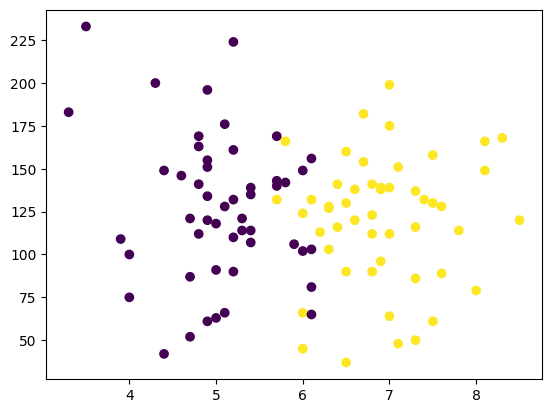

In [11]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [12]:
#Split the data into x and y such that x has independent data and y has dependent data
x=df.iloc[:,0:2]
y=df.iloc[:,-1]

In [13]:
x

,cgpa,iq
0,6.8,123
1,5.9,106
2,5.3,121
3,7.4,132
4,5.8,142
...,...,...
95,4.3,200
96,4.4,42
97,6.7,182
98,6.3,103


In [14]:
y

0     1
1     0
2     0
3     1
4     0
     ..
95    0
96    0
97    1
98    1
99    1
Name: placement, Length: 100, dtype: int64

In [15]:
#Again dividing the x data into x_train and x_test similarly y data also divided into y_test and y_train
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.1)

In [16]:
x_train

,cgpa,iq
25,5.0,91
36,5.7,140
9,5.1,66
50,3.5,233
91,7.5,158
...,...,...
29,7.0,112
39,4.6,146
78,6.1,81
27,6.0,124


In [17]:
x_test

,cgpa,iq
40,4.9,134
58,8.0,79
2,5.3,121
70,6.3,127
13,6.4,116
61,7.3,137
75,4.8,169
45,6.0,66
95,4.3,200
84,5.7,169


In [18]:
#Scaling is done to convert the input data into similar range so that model will learn easily
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)

In [19]:
x_train

array([[-8.76423898e-01, -7.96521435e-01],
       [-2.63608076e-01,  4.35990680e-01],
       [-7.88878781e-01, -1.42535415e+00],
       [-2.18960066e+00,  2.77524837e+00],
       [ 1.31220404e+00,  8.88750233e-01],
       [-9.63969016e-01,  7.12677074e-01],
       [ 1.83747474e+00,  6.62370457e-01],
       [ 8.74478451e-01,  1.92003588e+00],
       [ 4.36752864e-01, -8.21674744e-01],
       [ 2.01256498e+00,  1.14028332e+00],
       [-5.26243428e-01, -2.17995340e-01],
       [-2.63608076e-01,  5.11450606e-01],
       [ 6.11843099e-01,  7.88136999e-01],
       [ 5.24297981e-01, -6.70754893e-02],
       [ 6.99388216e-01,  8.38443616e-03],
       [-9.63969016e-01, -6.70754893e-02],
       [-7.01333663e-01,  2.54886859e+00],
       [ 1.13711380e+00, -1.67688723e-01],
       [-7.88878781e-01,  1.34150979e+00],
       [-2.36469089e+00,  1.51758295e+00],
       [-1.40169460e+00,  6.62370457e-01],
       [-1.05151413e+00,  4.61143989e-01],
       [ 2.18765521e+00, -6.70754893e-02],
       [ 5.

In [20]:
x_test

,cgpa,iq
40,4.9,134
58,8.0,79
2,5.3,121
70,6.3,127
13,6.4,116
61,7.3,137
75,4.8,169
45,6.0,66
95,4.3,200
84,5.7,169


In [21]:
x_test=scaler.transform(x_test)

In [22]:
x_test

array([[-9.63969016e-01,  2.85070830e-01],
       [ 1.74992963e+00, -1.09836114e+00],
       [-6.13788546e-01, -4.19221808e-02],
       [ 2.61662629e-01,  1.08997670e-01],
       [ 3.49207746e-01, -1.67688723e-01],
       [ 1.13711380e+00,  3.60530755e-01],
       [-1.05151413e+00,  1.16543663e+00],
       [-9.72723527e-04, -1.42535415e+00],
       [-1.48923972e+00,  1.94518919e+00],
       [-2.63608076e-01,  1.16543663e+00]])

In [23]:
#Training Data using logistic regression
from sklearn.linear_model import LogisticRegression

In [24]:
clf=LogisticRegression()

In [25]:
#Trasining model based on train data
clf.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [26]:
# Model Evaluation
#Our model prediction
y_pred=clf.predict(x_test)

In [27]:
# The actual value
y_test

40    0
58    1
2     0
70    1
13    1
61    1
75    0
45    1
95    0
84    0
Name: placement, dtype: int64

In [28]:
# This shows our model is doing wrong as you can see the 2nd person  has been placed (y data) but model says he is not placed (x predicted data)
# Hence now we will find the accuracy of our model 
from sklearn.metrics import accuracy_score

In [29]:
accuracy_score(y_test,y_pred)

0.9

In [30]:
!pip install mlxtend

  Using cached matplotlib-3.10.8-cp312-cp312-win_amd64.whl.metadata (52 kB)
Using cached matplotlib-3.10.8-cp312-cp312-win_amd64.whl (8.1 MB)
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.8.4
    Uninstalling matplotlib-3.8.4:


ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'c:\\users\\isha\\anaconda3\\lib\\site-packages\\matplotlib\\backends\\_backend_agg.cp312-win_amd64.pyd'
Consider using the `--user` option or check the permissions.


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [31]:
#Plotting decision boundary for visualization
from mlxtend.plotting import plot_decision_regions

<Axes: >

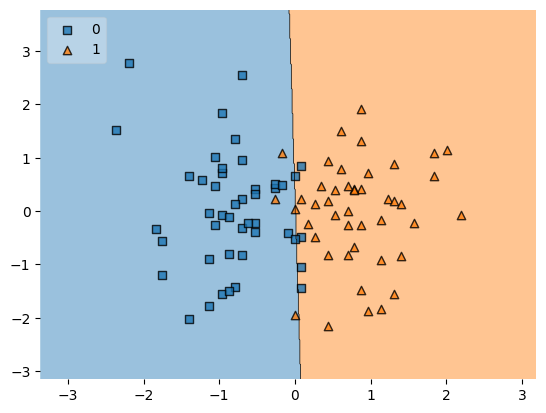

In [32]:
#x_train is already in array as standardized but y_train is not so we will use y_train.values
plot_decision_regions(x_train,y_train.values,clf=clf,legend=2)

In [66]:
import pickle

In [68]:
pickle.dump(clf,open('place.pkl','wb'))